In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))
from src.coils import coils
from src.field_solver import total_field_at_point

In [3]:
# ============================================================
# GRID SETTINGS
# ============================================================

z_plane = 0.0

Nx = 35
Ny = 35

x_vals = np.linspace(-2.0, 2.0, Nx)
y_vals = np.linspace(-2.0, 2.0, Ny)

X, Y = np.meshgrid(x_vals, y_vals)

In [4]:
coil_names = list(coils.keys())

print(coil_names)

['X1', 'X2', 'X3', 'Y1', 'Y2', 'Z1', 'Z2']


In [6]:
# ============================================================
# PRECOMPUTED UNIT-CURRENT FIELD MAPS
# ============================================================

field_maps = {}

mG_conversion = 1e7  # Tesla -> mG

for coil_name in coil_names:

    print(f"Computing maps for {coil_name} ...")

    currents = {name:0.0 for name in coil_names}
    currents[coil_name] = 1.0

    Bx_map = np.zeros((Ny, Nx))
    By_map = np.zeros((Ny, Nx))
    Bz_map = np.zeros((Ny, Nx))

    for i in range(Ny):

        for j in range(Nx):

            point = np.array([
                X[i,j],
                Y[i,j],
                z_plane
            ])

            B = total_field_at_point(
                point,
                coils,
                currents
            )

            # Convert to mG
            B *= mG_conversion

            Bx_map[i,j] = B[0]
            By_map[i,j] = B[1]
            Bz_map[i,j] = B[2]

    field_maps[coil_name] = {

        'Bx': Bx_map,
        'By': By_map,
        'Bz': Bz_map
    }

print("Done.")

Computing maps for X1 ...
Computing maps for X2 ...
Computing maps for X3 ...
Computing maps for Y1 ...
Computing maps for Y2 ...
Computing maps for Z1 ...
Computing maps for Z2 ...
Done.


In [7]:
# ============================================================
# CURRENT CONFIGURATION
# ============================================================

currents = {

    'X1': 68,
    'X2': 32,
    'X3': 68,

    'Y1': -23,
    'Y2': -23,

    'Z1': 72,
    'Z2': 72
}

# ============================================================
# AMBIENT FIELD
# ============================================================

Bx_ambient = -283.38
By_ambient = 106.79
Bz_ambient = -381.21

# ============================================================
# BUILD TOTAL FIELD MAPS
# ============================================================

Bx_total = np.full((Ny, Nx), Bx_ambient)
By_total = np.full((Ny, Nx), By_ambient)
Bz_total = np.full((Ny, Nx), Bz_ambient)

for coil_name, I in currents.items():

    Bx_total += I * field_maps[coil_name]['Bx']
    By_total += I * field_maps[coil_name]['By']
    Bz_total += I * field_maps[coil_name]['Bz']

Bmag_total = np.sqrt(
    Bx_total**2 +
    By_total**2 +
    Bz_total**2
)

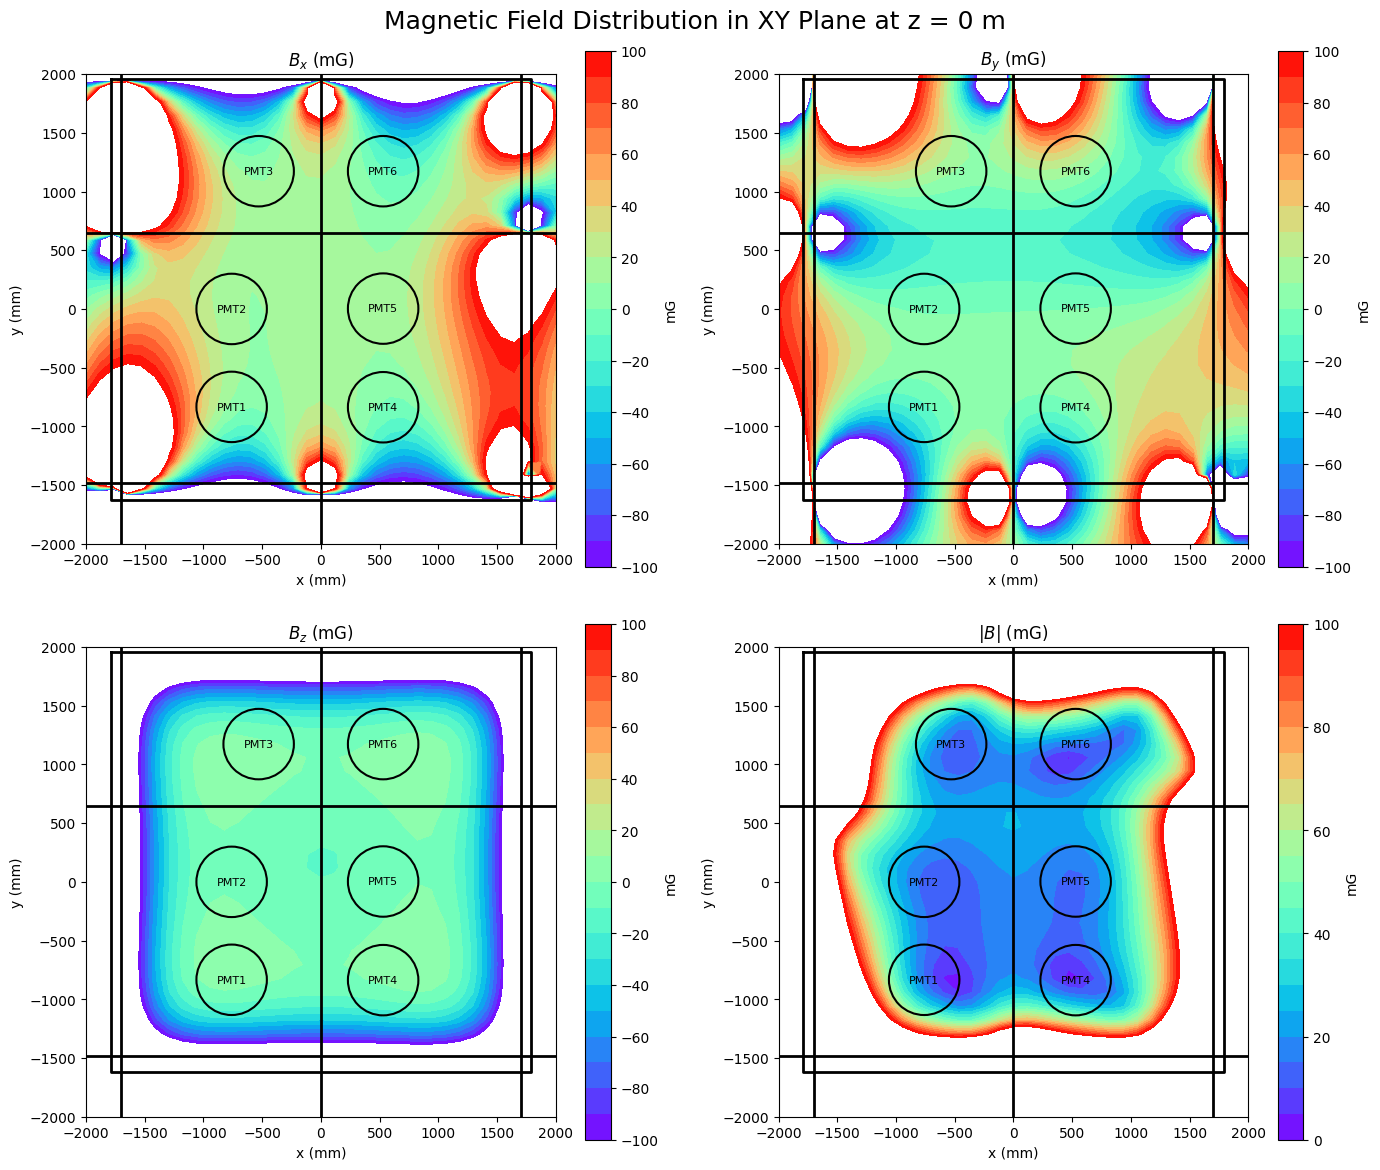

In [8]:
# ============================================================
# FIGURE 15 STYLE FIELD MAPS
# FOR z = 0 m
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# z PLANE
# ============================================================

z_plane = 0.0

# ============================================================
# PMT POSITIONS (mm)
# ============================================================

PMTs = {

    'PMT1': (-760, -834),
    'PMT2': (-760,    0),
    'PMT3': (-530, 1173),

    'PMT4': ( 530, -837),
    'PMT5': ( 530,    3),
    'PMT6': ( 530, 1173),
}

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,12)
)

# ============================================================
# FIELD COMPONENTS + COLOR SCALES
# ============================================================

plots = [

    (Bx_total, r'$B_x$ (mG)', -100, 100),
    (By_total, r'$B_y$ (mG)', -100, 100),
    (Bz_total, r'$B_z$ (mG)', -100, 100),
    (Bmag_total, r'$|B|$ (mG)', 0, 100)
]

# ============================================================
# LOOP OVER SUBPLOTS
# ============================================================

for ax, (data, title, vmin, vmax) in zip(axes.flat, plots):

    # --------------------------------------------------------
    # CONTOUR MAP
    # --------------------------------------------------------

    im = ax.contourf(

        X * 1000,
        Y * 1000,

        data,

        levels=np.linspace(vmin, vmax, 21),

        cmap='rainbow',

        vmin=vmin,
        vmax=vmax
    )

    # --------------------------------------------------------
    # COLORBAR
    # --------------------------------------------------------

    cbar = plt.colorbar(
        im,
        ax=ax
    )

    cbar.set_label('mG')

    if title != r'$|B|$ (mG)':

        cbar.set_ticks(
            np.arange(-100, 101, 20)
        )

    else:

        cbar.set_ticks(
            np.arange(0, 101, 20)
        )

    # --------------------------------------------------------
    # PMT CIRCLES
    # --------------------------------------------------------

    for name, (xp, yp) in PMTs.items():

        circle = plt.Circle(

            (xp, yp),

            300,          # radius in mm

            fill=False,
            color='black',
            linewidth=1.5
        )

        ax.add_patch(circle)

        ax.text(
            xp,
            yp,
            name,
            fontsize=8,
            ha='center',
            va='center'
        )

    # --------------------------------------------------------
    # X COILS (YZ plane)
    # projected into XY plane
    # --------------------------------------------------------

    for xcoil in [-1700, 0, 1700]:

        ax.axvline(
            x=xcoil,
            color='black',
            linewidth=2
        )

    # --------------------------------------------------------
    # Y COILS (XZ plane)
    # projected into XY plane
    # --------------------------------------------------------

    for ycoil in [648, -1482]:

        ax.axhline(
            y=ycoil,
            color='black',
            linewidth=2
        )

    # --------------------------------------------------------
    # Z COILS (XY plane)
    # actual rectangle
    # --------------------------------------------------------

    z_x0 = -1791
    z_y0 =  1959

    z_width = 3582
    z_height = 3582

    rect_x = [

        z_x0,
        z_x0 + z_width,
        z_x0 + z_width,
        z_x0,
        z_x0
    ]

    rect_y = [

        z_y0,
        z_y0,
        z_y0 - z_height,
        z_y0 - z_height,
        z_y0
    ]

    ax.plot(
        rect_x,
        rect_y,
        color='black',
        linewidth=2
    )

    # --------------------------------------------------------
    # AXIS LABELS
    # --------------------------------------------------------

    ax.set_title(title)

    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')

    ax.set_aspect('equal')

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    r'Magnetic Field Distribution in XY Plane at z = 0 m',
    fontsize=18
)

plt.tight_layout()

plt.show()

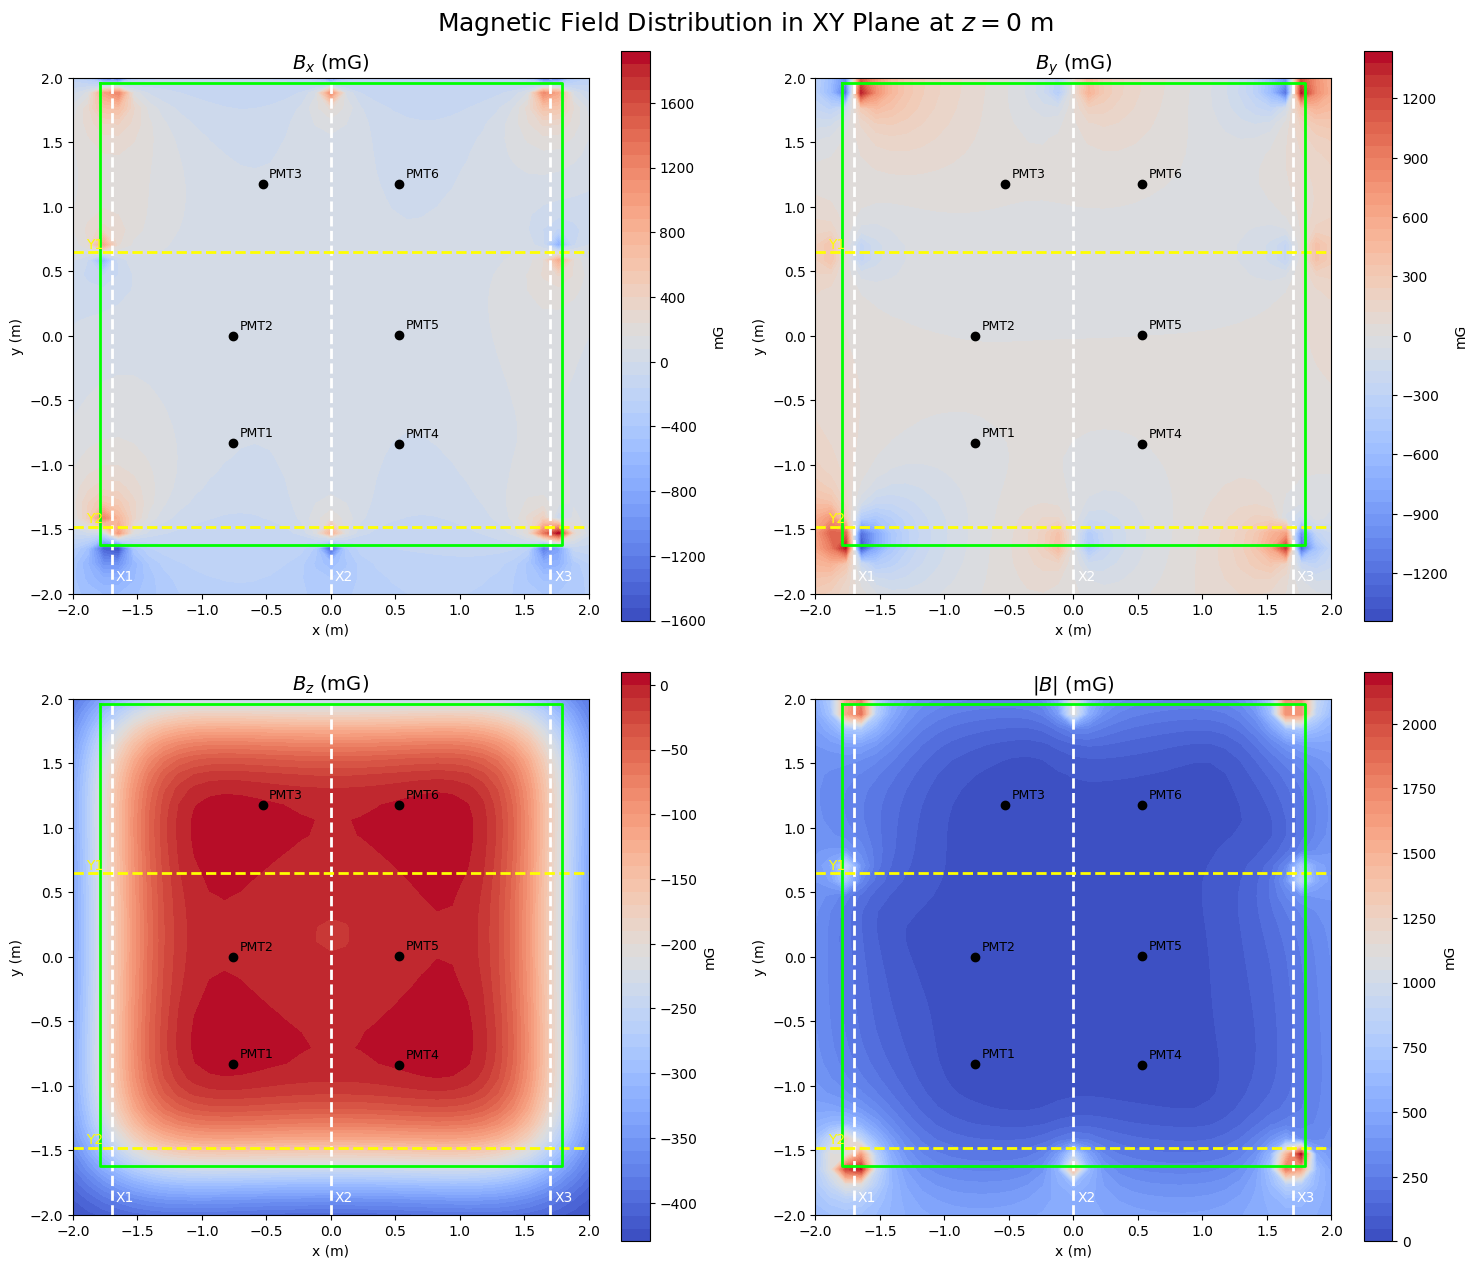

In [9]:
# ============================================================
# PLOT FIGURE 15 STYLE WITH:
# - PMT positions
# - Coil outlines projected onto XY plane
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 13))

plots = [

    (Bx_total, r'$B_x$ (mG)'),
    (By_total, r'$B_y$ (mG)'),
    (Bz_total, r'$B_z$ (mG)'),
    (Bmag_total, r'$|B|$ (mG)')
]

# ============================================================
# PMT POSITIONS
# ============================================================

PMTs = {

    'PMT1': (-0.760, -0.834, 0),
    'PMT2': (-0.760,  0.000, 0),
    'PMT3': (-0.530,  1.173, 0),

    'PMT4': ( 0.530, -0.837, 0),
    'PMT5': ( 0.530,  0.003, 0),
    'PMT6': ( 0.530,  1.173, 0),
}

# ============================================================
# COIL OUTLINES IN XY PROJECTION
# ============================================================

coil_lines = [

    # --------------------------------------------------------
    # X coils (YZ plane)
    # In XY projection:
    # become vertical lines at x = const
    # --------------------------------------------------------

    ('X1', -1.700),
    ('X2',  0.000),
    ('X3',  1.700),

    # --------------------------------------------------------
    # Y coils (XZ plane)
    # In XY projection:
    # become horizontal lines at y = const
    # --------------------------------------------------------

    ('Y1',  0.648),
    ('Y2', -1.482),

    # --------------------------------------------------------
    # Z coils are in XY plane themselves
    # draw actual rectangles
    # --------------------------------------------------------
]

# ============================================================
# LOOP OVER SUBPLOTS
# ============================================================

for ax, (data, title) in zip(axes.flat, plots):

    # --------------------------------------------------------
    # FIELD MAP
    # --------------------------------------------------------

    im = ax.contourf(
        X,
        Y,
        data,
        levels=50,
        cmap='coolwarm'
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('mG')

    # --------------------------------------------------------
    # PMTs
    # --------------------------------------------------------

    for name, (xp, yp, zp) in PMTs.items():

        ax.plot(
            xp,
            yp,
            'ko',
            markersize=6
        )

        ax.text(
            xp + 0.05,
            yp + 0.05,
            name,
            fontsize=9,
            color='black'
        )

    # --------------------------------------------------------
    # X coils projection
    # --------------------------------------------------------

    for name, xcoil in coil_lines[:3]:

        ax.axvline(
            x=xcoil,
            linestyle='--',
            linewidth=2,
            color='white'
        )

        ax.text(
            xcoil + 0.03,
            -1.9,
            name,
            color='white',
            fontsize=10
        )

    # --------------------------------------------------------
    # Y coils projection
    # --------------------------------------------------------

    for name, ycoil in coil_lines[3:5]:

        ax.axhline(
            y=ycoil,
            linestyle='--',
            linewidth=2,
            color='yellow'
        )

        ax.text(
            -1.9,
            ycoil + 0.03,
            name,
            color='yellow',
            fontsize=10
        )

    # --------------------------------------------------------
    # Z coil rectangles
    # --------------------------------------------------------

    z_x0 = -1.791
    z_y0 =  1.959

    z_width = 3.582
    z_height = 3.582

    rect_x = [

        z_x0,
        z_x0 + z_width,
        z_x0 + z_width,
        z_x0,
        z_x0
    ]

    rect_y = [

        z_y0,
        z_y0,
        z_y0 - z_height,
        z_y0 - z_height,
        z_y0
    ]

    ax.plot(
        rect_x,
        rect_y,
        color='lime',
        linewidth=2
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_title(title, fontsize=14)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')

    ax.set_aspect('equal')

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    r'Magnetic Field Distribution in XY Plane at $z=0$ m',
    fontsize=18
)

plt.tight_layout()

plt.show()

In [10]:
# ============================================================
# SAVE FIELD MAPS INTO data/ FOLDER
# ============================================================

import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Path to project root
# (Notebook is inside notebooks/)
# ------------------------------------------------------------

project_root = Path.cwd().parent

# ------------------------------------------------------------
# data folder path
# ------------------------------------------------------------

data_dir = project_root / "data"

# ------------------------------------------------------------
# Create filename
# ------------------------------------------------------------

save_path = data_dir / "field_maps_z0.npz"

# ============================================================
# SAVE
# ============================================================

np.savez(

    save_path,

    field_maps=field_maps,

    X=X,
    Y=Y,

    z_plane=z_plane
)

print(f"Saved field maps to:\n{save_path}")

Saved field maps to:
C:\Users\Guru Jahnavi Madana\magnetic_compensation\data\field_maps_z0.npz


In [ ]:
# ============================================================
# PRECOMPUTE + SAVE FIELD MAPS FOR z = +0.5 m
# ============================================================

import numpy as np
from pathlib import Path

# ============================================================
# Z PLANE
# ============================================================

z_plane = 0.5   # +50 cm

print(f"\nComputing field maps for z = {z_plane} m\n")

# ============================================================
# GRID
# ============================================================

Nx = 35
Ny = 35

x_vals = np.linspace(-2.0, 2.0, Nx)
y_vals = np.linspace(-2.0, 2.0, Ny)

X, Y = np.meshgrid(x_vals, y_vals)

# ============================================================
# PRECOMPUTE UNIT-CURRENT FIELD MAPS
# ============================================================

field_maps = {}

mG_conversion = 1e7  # Tesla -> mG

for coil_name in coil_names:

    print(f"Computing maps for {coil_name} ...")

    currents = {name:0.0 for name in coil_names}
    currents[coil_name] = 1.0

    Bx_map = np.zeros((Ny, Nx))
    By_map = np.zeros((Ny, Nx))
    Bz_map = np.zeros((Ny, Nx))

    for i in range(Ny):

        for j in range(Nx):

            point = np.array([
                X[i,j],
                Y[i,j],
                z_plane
            ])

            B = total_field_at_point(
                point,
                coils,
                currents
            )

            # Tesla -> mG
            B *= mG_conversion

            Bx_map[i,j] = B[0]
            By_map[i,j] = B[1]
            Bz_map[i,j] = B[2]

    field_maps[coil_name] = {

        'Bx': Bx_map,
        'By': By_map,
        'Bz': Bz_map
    }

print("\nFinished computing maps.\n")

# ============================================================
# SAVE TO data/
# ============================================================

project_root = Path.cwd().parent

data_dir = project_root / "data"

save_path = data_dir / "field_maps_zp05.npz"

np.savez(

    save_path,

    field_maps=field_maps,

    X=X,
    Y=Y,

    z_plane=z_plane
)

print(f"Saved field maps to:\n{save_path}")

In [ ]:
# ============================================================
# PRECOMPUTE + SAVE FIELD MAPS FOR z = -0.5 m
# ============================================================

import numpy as np
from pathlib import Path

# ============================================================
# Z PLANE
# ============================================================

z_plane = -0.5   # -50 cm

print(f"\nComputing field maps for z = {z_plane} m\n")

# ============================================================
# GRID
# ============================================================

Nx = 35
Ny = 35

x_vals = np.linspace(-2.0, 2.0, Nx)
y_vals = np.linspace(-2.0, 2.0, Ny)

X, Y = np.meshgrid(x_vals, y_vals)

# ============================================================
# PRECOMPUTE UNIT-CURRENT FIELD MAPS
# ============================================================

field_maps = {}

mG_conversion = 1e7  # Tesla -> mG

for coil_name in coil_names:

    print(f"Computing maps for {coil_name} ...")

    currents = {name:0.0 for name in coil_names}
    currents[coil_name] = 1.0

    Bx_map = np.zeros((Ny, Nx))
    By_map = np.zeros((Ny, Nx))
    Bz_map = np.zeros((Ny, Nx))

    for i in range(Ny):

        for j in range(Nx):

            point = np.array([
                X[i,j],
                Y[i,j],
                z_plane
            ])

            B = total_field_at_point(
                point,
                coils,
                currents
            )

            # Tesla -> mG
            B *= mG_conversion

            Bx_map[i,j] = B[0]
            By_map[i,j] = B[1]
            Bz_map[i,j] = B[2]

    field_maps[coil_name] = {

        'Bx': Bx_map,
        'By': By_map,
        'Bz': Bz_map
    }

print("\nFinished computing maps.\n")

# ============================================================
# SAVE TO data/
# ============================================================

project_root = Path.cwd().parent

data_dir = project_root / "data"

save_path = data_dir / "field_maps_zm05.npz"

np.savez(

    save_path,

    field_maps=field_maps,

    X=X,
    Y=Y,

    z_plane=z_plane
)

print(f"Saved field maps to:\n{save_path}")

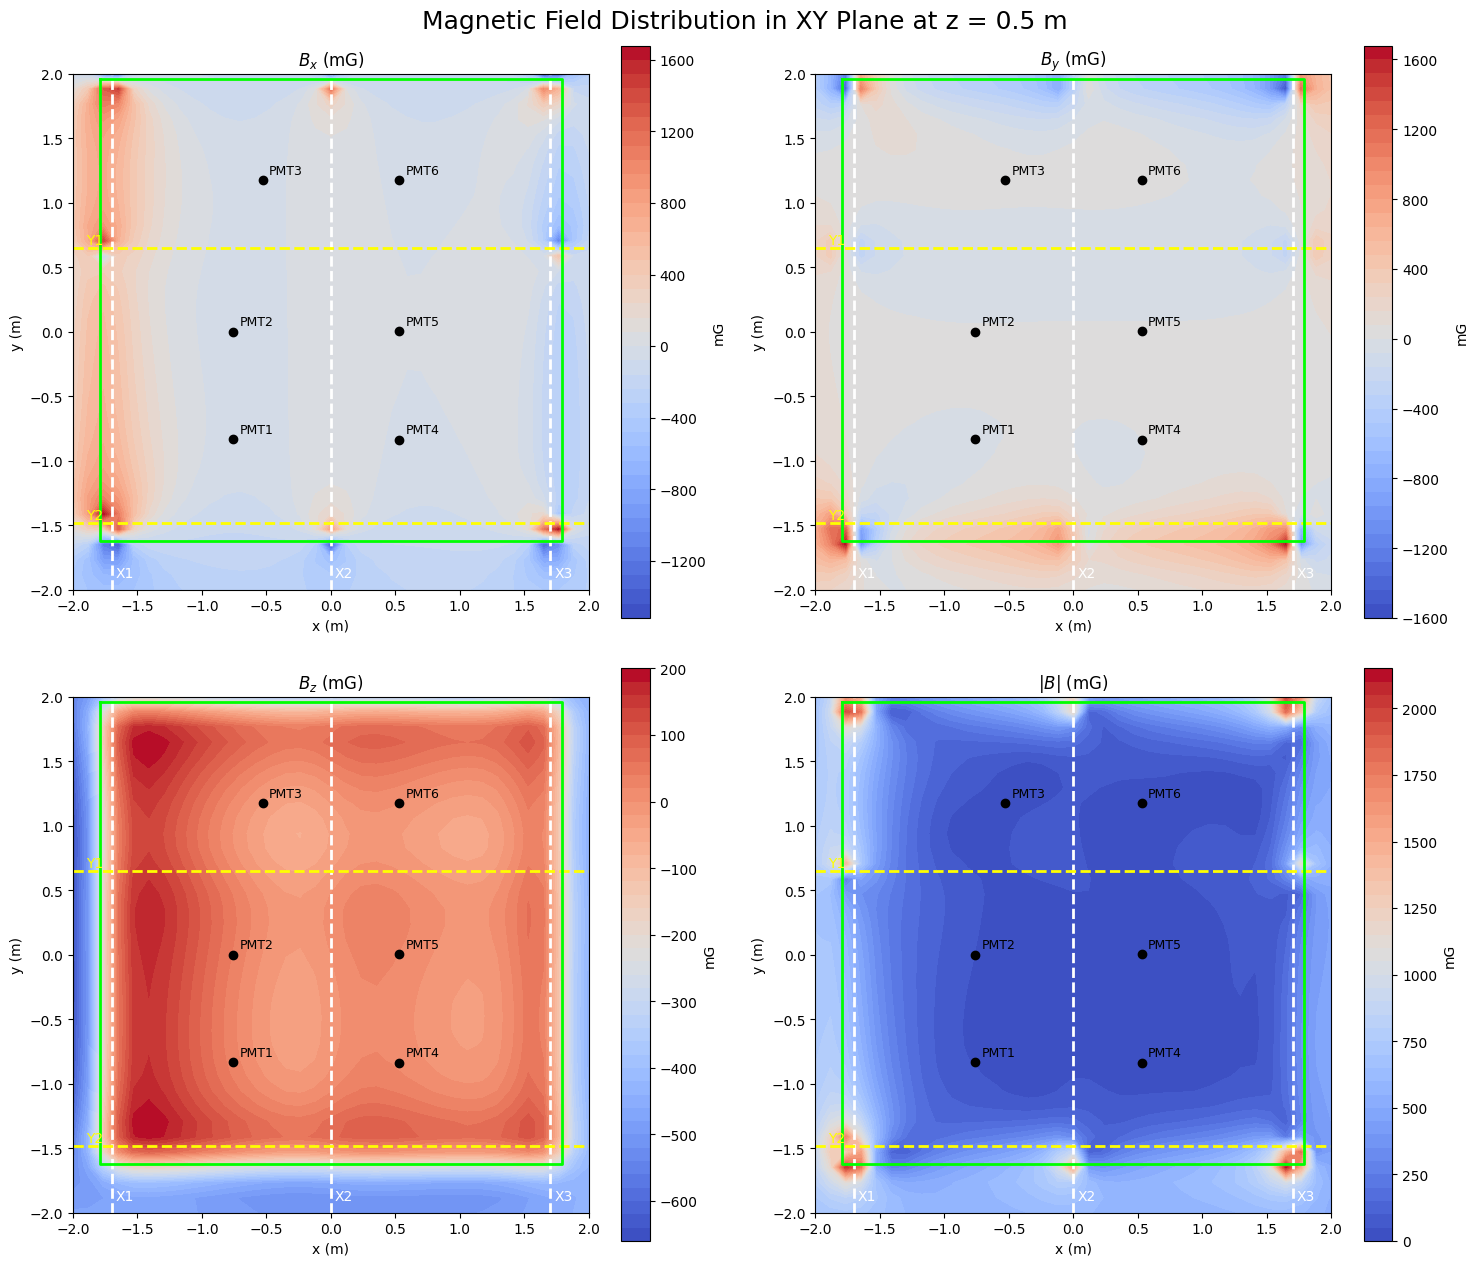

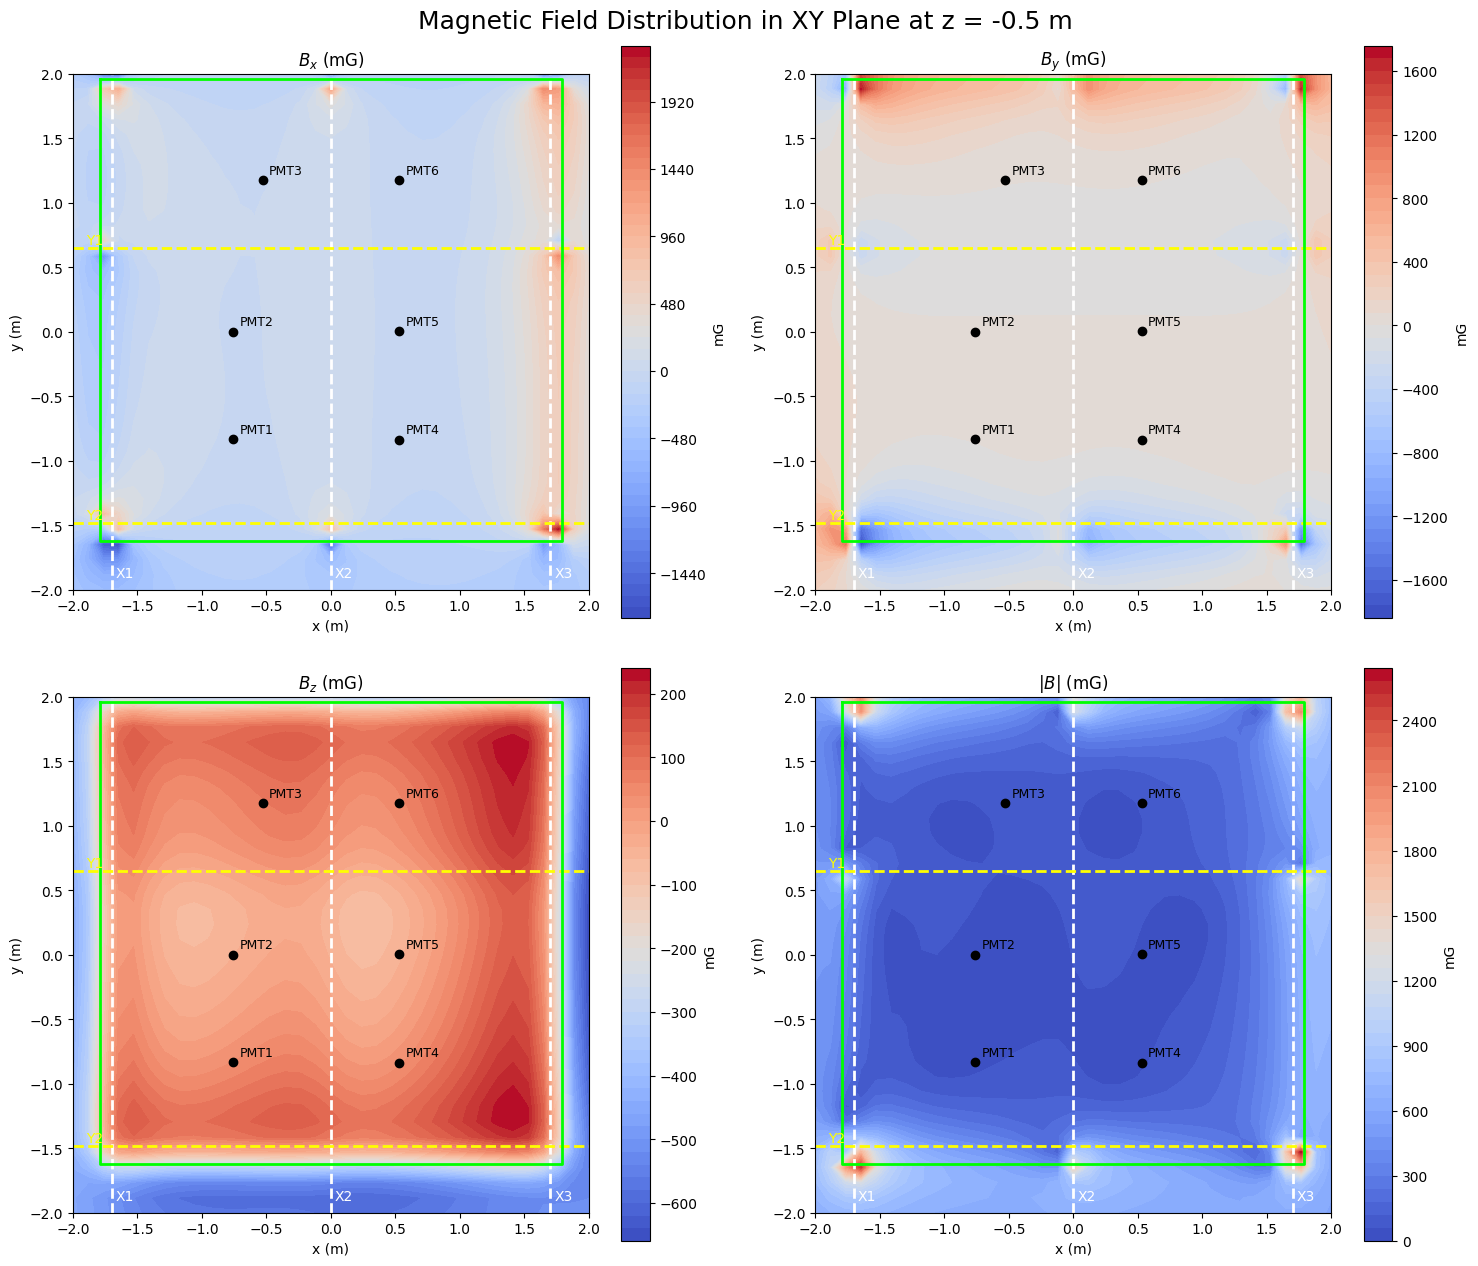

In [11]:
# ============================================================
# LOAD + PLOT FIELD MAPS
# FOR z = +0.5 m AND z = -0.5 m
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# LOAD FIELD MAPS
# ============================================================

project_root = Path.cwd().parent
data_dir = project_root / "data"

# ------------------------------------------------------------
# +0.5 m maps
# ------------------------------------------------------------

data_p = np.load(
    data_dir / "field_maps_zp05.npz",
    allow_pickle=True
)

field_maps_p = data_p['field_maps'].item()

X = data_p['X']
Y = data_p['Y']

# ------------------------------------------------------------
# -0.5 m maps
# ------------------------------------------------------------

data_m = np.load(
    data_dir / "field_maps_zm05.npz",
    allow_pickle=True
)

field_maps_m = data_m['field_maps'].item()

# ============================================================
# CURRENT CONFIGURATION
# ============================================================

currents = {

    'X1': 68,
    'X2': 32,
    'X3': 68,

    'Y1': -23,
    'Y2': -23,

    'Z1': 72,
    'Z2': 72
}

# ============================================================
# AMBIENT FIELD (mG)
# ============================================================

Bx_ambient = -283.38
By_ambient =  106.79
Bz_ambient = -381.21

# ============================================================
# FUNCTION TO BUILD TOTAL FIELD MAPS
# ============================================================

def build_total_maps(field_maps):

    Ny, Nx = X.shape

    Bx_total = np.full((Ny, Nx), Bx_ambient)
    By_total = np.full((Ny, Nx), By_ambient)
    Bz_total = np.full((Ny, Nx), Bz_ambient)

    for coil_name, I in currents.items():

        Bx_total += I * field_maps[coil_name]['Bx']
        By_total += I * field_maps[coil_name]['By']
        Bz_total += I * field_maps[coil_name]['Bz']

    Bmag_total = np.sqrt(
        Bx_total**2 +
        By_total**2 +
        Bz_total**2
    )

    return Bx_total, By_total, Bz_total, Bmag_total

# ============================================================
# BUILD MAPS
# ============================================================

Bx_p, By_p, Bz_p, Bmag_p = build_total_maps(field_maps_p)

Bx_m, By_m, Bz_m, Bmag_m = build_total_maps(field_maps_m)

# ============================================================
# PMT POSITIONS
# ============================================================

PMTs = {

    'PMT1': (-0.760, -0.834, 0),
    'PMT2': (-0.760,  0.000, 0),
    'PMT3': (-0.530,  1.173, 0),

    'PMT4': ( 0.530, -0.837, 0),
    'PMT5': ( 0.530,  0.003, 0),
    'PMT6': ( 0.530,  1.173, 0),
}

# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_maps(Bx, By, Bz, Bmag, z_value):

    fig, axes = plt.subplots(2, 2, figsize=(15,13))

    plots = [

        (Bx, r'$B_x$ (mG)'),
        (By, r'$B_y$ (mG)'),
        (Bz, r'$B_z$ (mG)'),
        (Bmag, r'$|B|$ (mG)')
    ]

    for ax, (data, title) in zip(axes.flat, plots):

        im = ax.contourf(
            X,
            Y,
            data,
            levels=50,
            cmap='coolwarm'
        )

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('mG')

        # ----------------------------------------------------
        # PMTs
        # ----------------------------------------------------

        for name, (xp, yp, zp) in PMTs.items():

            ax.plot(
                xp,
                yp,
                'ko',
                markersize=6
            )

            ax.text(
                xp + 0.05,
                yp + 0.05,
                name,
                fontsize=9,
                color='black'
            )

        # ----------------------------------------------------
        # X coil projections
        # ----------------------------------------------------

        for xcoil, label in zip(
            [-1.700, 0.0, 1.700],
            ['X1','X2','X3']
        ):

            ax.axvline(
                x=xcoil,
                linestyle='--',
                linewidth=2,
                color='white'
            )

            ax.text(
                xcoil + 0.03,
                -1.9,
                label,
                color='white'
            )

        # ----------------------------------------------------
        # Y coil projections
        # ----------------------------------------------------

        for ycoil, label in zip(
            [0.648, -1.482],
            ['Y1','Y2']
        ):

            ax.axhline(
                y=ycoil,
                linestyle='--',
                linewidth=2,
                color='yellow'
            )

            ax.text(
                -1.9,
                ycoil + 0.03,
                label,
                color='yellow'
            )

        # ----------------------------------------------------
        # Z coil rectangle
        # ----------------------------------------------------

        z_x0 = -1.791
        z_y0 =  1.959

        z_width = 3.582
        z_height = 3.582

        rect_x = [

            z_x0,
            z_x0 + z_width,
            z_x0 + z_width,
            z_x0,
            z_x0
        ]

        rect_y = [

            z_y0,
            z_y0,
            z_y0 - z_height,
            z_y0 - z_height,
            z_y0
        ]

        ax.plot(
            rect_x,
            rect_y,
            color='lime',
            linewidth=2
        )

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        ax.set_title(title)

        ax.set_xlabel('x (m)')
        ax.set_ylabel('y (m)')

        ax.set_aspect('equal')

    fig.suptitle(
        rf'Magnetic Field Distribution in XY Plane at z = {z_value:.1f} m',
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# PLOT BOTH PLANES
# ============================================================

plot_maps(Bx_p, By_p, Bz_p, Bmag_p, +0.5)

plot_maps(Bx_m, By_m, Bz_m, Bmag_m, -0.5)

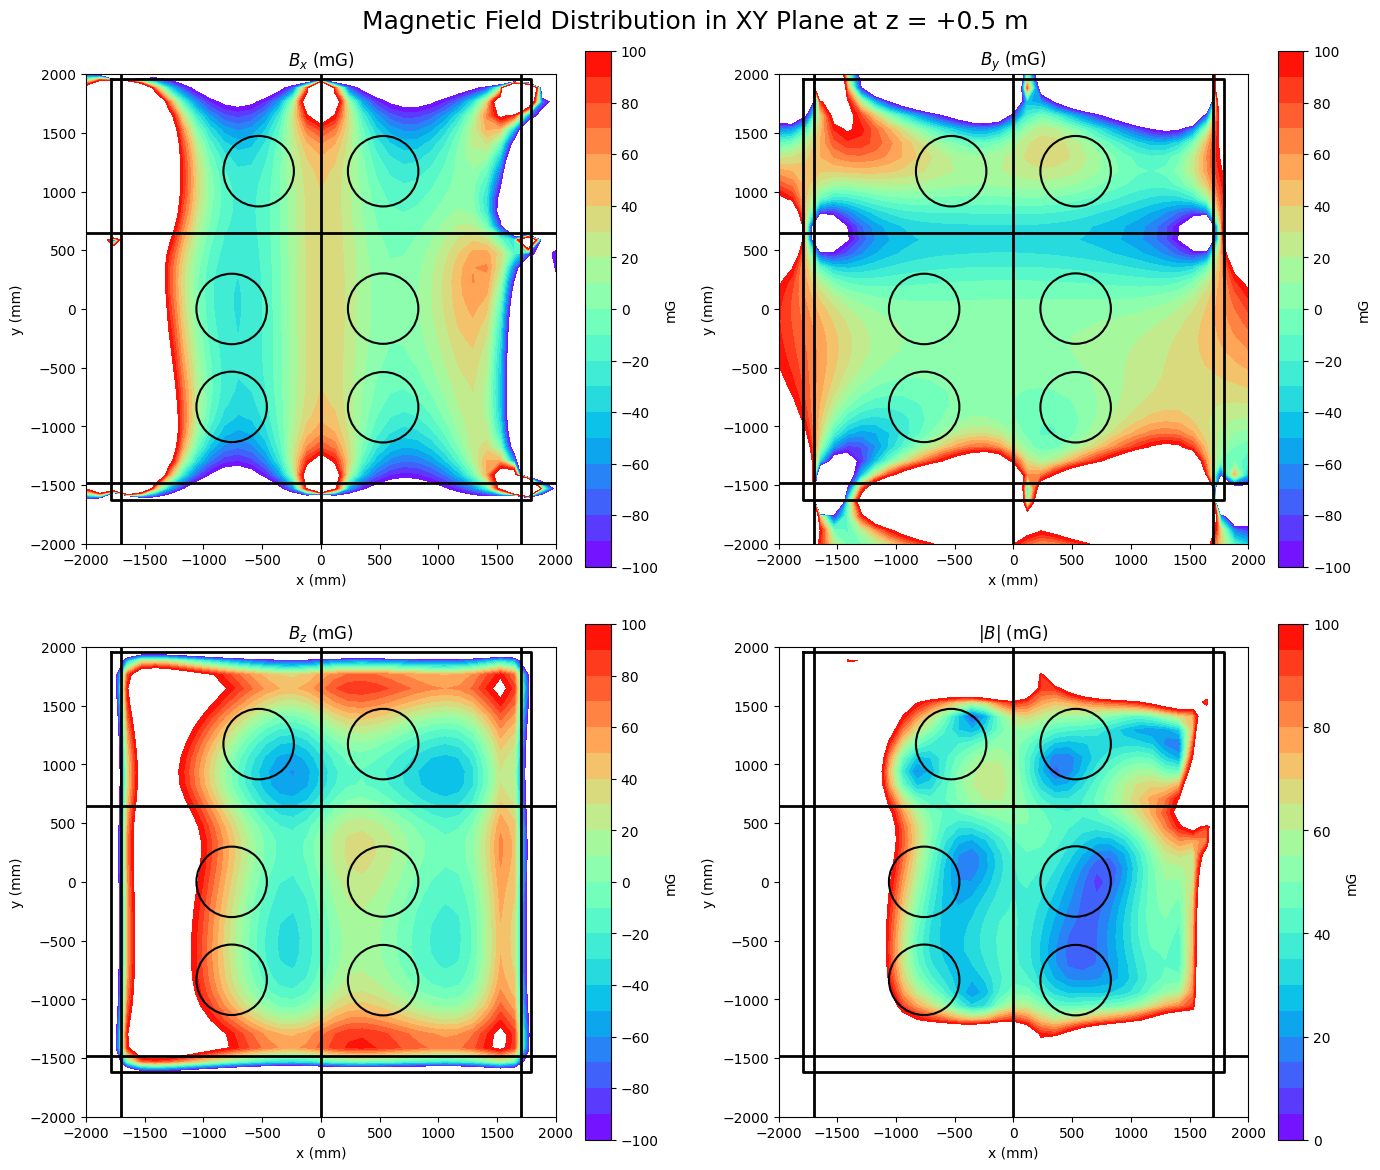

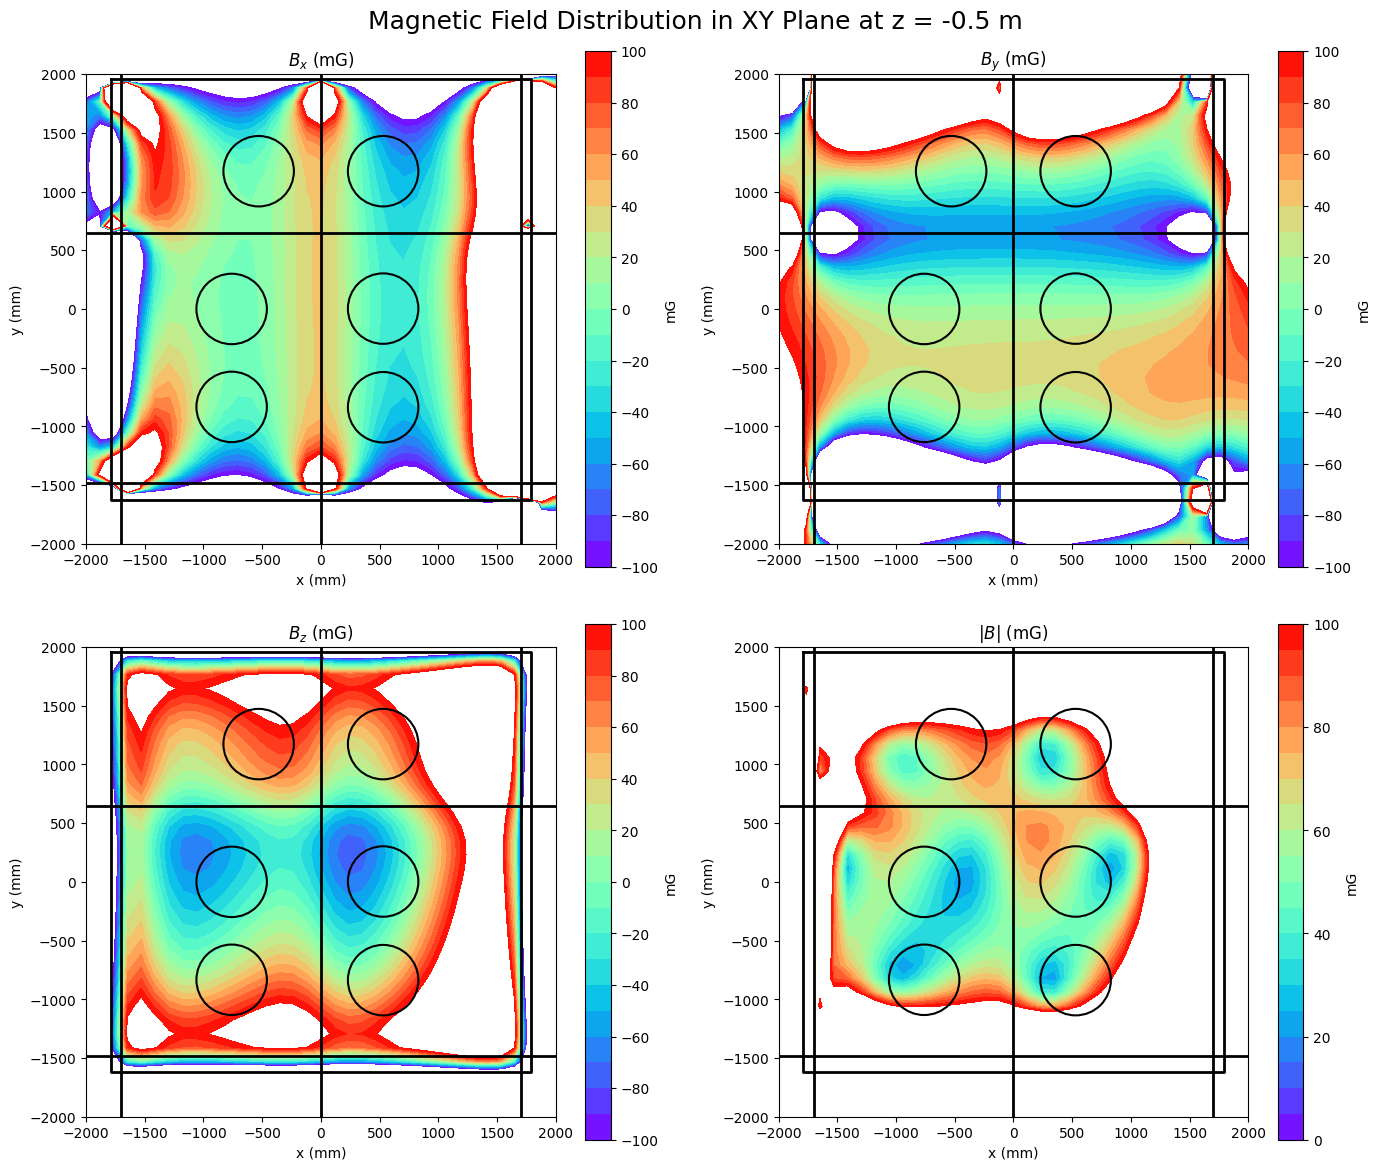

In [12]:
# ============================================================
# LOAD FIELD MAPS
# BUILD TOTAL FIELD INCLUDING AMBIENT FIELD
# PLOT FIGURE-15 STYLE MAPS
# FOR z = +0.5 m AND z = -0.5 m
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# LOAD DATA
# ============================================================

project_root = Path.cwd().parent
data_dir = project_root / "data"

# ------------------------------------------------------------
# +0.5 m maps
# ------------------------------------------------------------

data_p = np.load(
    data_dir / "field_maps_zp05.npz",
    allow_pickle=True
)

field_maps_p = data_p['field_maps'].item()

X = data_p['X']
Y = data_p['Y']

# ------------------------------------------------------------
# -0.5 m maps
# ------------------------------------------------------------

data_m = np.load(
    data_dir / "field_maps_zm05.npz",
    allow_pickle=True
)

field_maps_m = data_m['field_maps'].item()

# ============================================================
# CURRENTS (TABLE 6)
# ============================================================

currents = {

    'X1': 68,
    'X2': 32,
    'X3': 68,

    'Y1': -23,
    'Y2': -23,

    'Z1': 72,
    'Z2': 72
}

# ============================================================
# AMBIENT FIELD (mG)
# ============================================================

Bx_ambient = -283.38
By_ambient =  106.79
Bz_ambient = -381.21

# ============================================================
# BUILD TOTAL FIELD MAPS
# ============================================================

def build_total_maps(field_maps, currents):

    # --------------------------------------------------------
    # COIL FIELD
    # --------------------------------------------------------

    Bx_total = np.zeros_like(X)
    By_total = np.zeros_like(X)
    Bz_total = np.zeros_like(X)

    for coil_name, I in currents.items():

        Bx_total += I * field_maps[coil_name]['Bx']
        By_total += I * field_maps[coil_name]['By']
        Bz_total += I * field_maps[coil_name]['Bz']

    # --------------------------------------------------------
    # ADD AMBIENT FIELD
    # --------------------------------------------------------

    Bx_total += Bx_ambient
    By_total += By_ambient
    Bz_total += Bz_ambient

    # --------------------------------------------------------
    # MAGNITUDE
    # --------------------------------------------------------

    Bmag_total = np.sqrt(

        Bx_total**2 +
        By_total**2 +
        Bz_total**2
    )

    return Bx_total, By_total, Bz_total, Bmag_total

# ============================================================
# BUILD TOTAL MAPS
# ============================================================

Bx_p, By_p, Bz_p, Bmag_p = build_total_maps(
    field_maps_p,
    currents
)

Bx_m, By_m, Bz_m, Bmag_m = build_total_maps(
    field_maps_m,
    currents
)

# ============================================================
# PMT POSITIONS (mm)
# ============================================================

PMTs = {

    'PMT1': (-760, -834),
    'PMT2': (-760,    0),
    'PMT3': (-530, 1173),

    'PMT4': ( 530, -837),
    'PMT5': ( 530,    3),
    'PMT6': ( 530, 1173),
}

# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_maps(
    Bx_total,
    By_total,
    Bz_total,
    Bmag_total,
    z_title
):

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14,12)
    )

    plots = [

        (Bx_total, r'$B_x$ (mG)', -100, 100),
        (By_total, r'$B_y$ (mG)', -100, 100),
        (Bz_total, r'$B_z$ (mG)', -100, 100),
        (Bmag_total, r'$|B|$ (mG)', 0, 100)
    ]

    for ax, (data, title, vmin, vmax) in zip(axes.flat, plots):

        # ----------------------------------------------------
        # CONTOUR MAP
        # ----------------------------------------------------

        im = ax.contourf(

            X * 1000,
            Y * 1000,

            data,

            levels=np.linspace(vmin, vmax, 21),

            cmap='rainbow',

            vmin=vmin,
            vmax=vmax
        )

        # ----------------------------------------------------
        # COLORBAR
        # ----------------------------------------------------

        cbar = plt.colorbar(
            im,
            ax=ax
        )

        cbar.set_label('mG')

        if title != r'$|B|$ (mG)':

            cbar.set_ticks(
                np.arange(-100, 101, 20)
            )

        else:

            cbar.set_ticks(
                np.arange(0, 101, 20)
            )

        # ----------------------------------------------------
        # PMT CIRCLES
        # ----------------------------------------------------

        for name, (xp, yp) in PMTs.items():

            circle = plt.Circle(

                (xp, yp),

                300,

                fill=False,
                color='black',
                linewidth=1.5
            )

            ax.add_patch(circle)

        # ----------------------------------------------------
        # X COILS
        # ----------------------------------------------------

        for xcoil in [-1700, 0, 1700]:

            ax.axvline(
                x=xcoil,
                color='black',
                linewidth=2
            )

        # ----------------------------------------------------
        # Y COILS
        # ----------------------------------------------------

        for ycoil in [648, -1482]:

            ax.axhline(
                y=ycoil,
                color='black',
                linewidth=2
            )

        # ----------------------------------------------------
        # Z COIL RECTANGLE
        # ----------------------------------------------------

        z_x0 = -1791
        z_y0 =  1959

        z_width = 3582
        z_height = 3582

        rect_x = [

            z_x0,
            z_x0 + z_width,
            z_x0 + z_width,
            z_x0,
            z_x0
        ]

        rect_y = [

            z_y0,
            z_y0,
            z_y0 - z_height,
            z_y0 - z_height,
            z_y0
        ]

        ax.plot(
            rect_x,
            rect_y,
            color='black',
            linewidth=2
        )

        # ----------------------------------------------------
        # LABELS
        # ----------------------------------------------------

        ax.set_title(title)

        ax.set_xlabel('x (mm)')
        ax.set_ylabel('y (mm)')

        ax.set_aspect('equal')

    fig.suptitle(
        z_title,
        fontsize=18
    )

    plt.tight_layout()

    plt.show()

# ============================================================
# PLOT z = +0.5 m
# ============================================================

plot_maps(

    Bx_p,
    By_p,
    Bz_p,
    Bmag_p,

    r'Magnetic Field Distribution in XY Plane at z = +0.5 m'
)

# ============================================================
# PLOT z = -0.5 m
# ============================================================

plot_maps(

    Bx_m,
    By_m,
    Bz_m,
    Bmag_m,

    r'Magnetic Field Distribution in XY Plane at z = -0.5 m'
)

In [13]:
# ============================================================
# PRINT FIELD VALUES AT PMT POSITIONS
# FOR:
# z = 0
# z = +0.5 m
# z = -0.5 m
# ============================================================

import numpy as np

# ============================================================
# PMT POSITIONS
# ============================================================

PMTs = {

    'PMT1': (-0.760, -0.834, 0),
    'PMT2': (-0.760,  0.000, 0),
    'PMT3': (-0.530,  1.173, 0),

    'PMT4': ( 0.530, -0.837, 0),
    'PMT5': ( 0.530,  0.003, 0),
    'PMT6': ( 0.530,  1.173, 0),
}

# ============================================================
# CURRENTS
# ============================================================

currents = {

    'X1': 68,
    'X2': 32,
    'X3': 68,

    'Y1': -23,
    'Y2': -23,

    'Z1': 72,
    'Z2': 72
}

# ============================================================
# AMBIENT FIELD (mG)
# ============================================================

B_ambient = np.array([
    -283.38,
     106.79,
    -381.21
])

# ============================================================
# PLANES TO TEST
# ============================================================

z_planes = [0.0, 0.5, -0.5]

# ============================================================
# LOOP OVER PLANES
# ============================================================

for z_plane in z_planes:

    print("\n")
    print("="*60)
    print(f"FIELD AT PMTs FOR z = {z_plane:.1f} m")
    print("="*60)

    for pmt_name, (x, y, _) in PMTs.items():

        point = np.array([x, y, z_plane])

        # ----------------------------------------------------
        # TOTAL FIELD FROM ALL COILS
        # ----------------------------------------------------

        B_total = total_field_at_point(
            point,
            coils,
            currents
        )

        # Tesla -> mG
        B_total *= 1e7

        # ----------------------------------------------------
        # ADD AMBIENT FIELD
        # ----------------------------------------------------

        B_total += B_ambient

        # ----------------------------------------------------
        # MAGNITUDE
        # ----------------------------------------------------

        Bmag = np.linalg.norm(B_total)

        # ----------------------------------------------------
        # PRINT
        # ----------------------------------------------------

        print(f"\n{pmt_name}")
        print("-"*30)

        print(f"Bx   = {B_total[0]:8.2f} mG")
        print(f"By   = {B_total[1]:8.2f} mG")
        print(f"Bz   = {B_total[2]:8.2f} mG")
        print(f"|B|  = {Bmag:8.2f} mG")



FIELD AT PMTs FOR z = 0.0 m

PMT1
------------------------------
Bx   =     5.89 mG
By   =   -12.73 mG
Bz   =     4.42 mG
|B|  =    14.71 mG

PMT2
------------------------------
Bx   =    12.71 mG
By   =    -1.58 mG
Bz   =    -1.34 mG
|B|  =    12.88 mG

PMT3
------------------------------
Bx   =     7.01 mG
By   =    10.61 mG
Bz   =     2.16 mG
|B|  =    12.89 mG

PMT4
------------------------------
Bx   =    -2.71 mG
By   =    -1.33 mG
Bz   =     1.87 mG
|B|  =     3.55 mG

PMT5
------------------------------
Bx   =    12.83 mG
By   =    -0.33 mG
Bz   =    -4.47 mG
|B|  =    13.59 mG

PMT6
------------------------------
Bx   =    -9.23 mG
By   =    11.20 mG
Bz   =     2.10 mG
|B|  =    14.66 mG


FIELD AT PMTs FOR z = 0.5 m

PMT1
------------------------------
Bx   =   -34.23 mG
By   =    -9.35 mG
Bz   =    30.00 mG
|B|  =    46.47 mG

PMT2
------------------------------
Bx   =   -30.43 mG
By   =     3.36 mG
Bz   =    37.73 mG
|B|  =    48.59 mG

PMT3
------------------------------